In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.applications import MobileNetV2
import matplotlib.pyplot as plt

# -----------------------------
# CONFIGURATION
# -----------------------------

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 15

DATASET_PATH = r"/home/ravjot/datasets/Pomegranate Diseases Dataset"
# -----------------------------

I0000 00:00:1775634184.356155    2035 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# -----------------------------
# DATA LOADING
# -----------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

Found 5099 files belonging to 5 classes.
Using 4080 files for training.


I0000 00:00:1775634193.973236    2035 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 5099 files belonging to 5 classes.
Using 1019 files for validation.


In [3]:
# -----------------------------
# DATA AUGMENTATION
# -----------------------------

data_augmentation = keras.Sequential([
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.2),
    keras.layers.RandomFlip("horizontal"),
])

In [ ]:
# -----------------------------
# PREPROCESSING
# -----------------------------

preprocess = keras.applications.mobilenet_v2.preprocess_input

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [5]:
# -----------------------------
# MODEL ARCHITECTURE
# -----------------------------

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# freeze base model
base_model.trainable = False

inputs = keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = preprocess(x)

x = base_model(x, training=False)

# GlobalAveragePooling layer
x = keras.layers.GlobalAveragePooling2D()(x)

# Dropout layer (0.3)
x = keras.layers.Dropout(0.3)(x)

# Dense layer (128 units)
x = keras.layers.Dense(128, activation="relu")(x)

# Second Dropout
x = keras.layers.Dropout(0.3)(x)

# Output layer
outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

In [6]:
# -----------------------------
# COMPILE MODEL
# -----------------------------

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# -----------------------------
# CALLBACKS
# -----------------------------

callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ModelCheckpoint(
        "best_mobilenet_pomegranate.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [8]:
# -----------------------------
# TRAIN MODEL
# -----------------------------

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15


I0000 00:00:1775634210.040769    2177 cuda_dnn.cc:461] Loaded cuDNN version 91002


128/128 ━━━━━━━━━━━━━━━━━━━━ 35s 190ms/step - accuracy: 0.6294 - loss: 0.9789 - val_accuracy: 0.9244 - val_loss: 0.3413
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 25s 192ms/step - accuracy: 0.8730 - loss: 0.3913 - val_accuracy: 0.9490 - val_loss: 0.1918
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - accuracy: 0.9118 - loss: 0.2712 - val_accuracy: 0.9549 - val_loss: 0.1507
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 22s 173ms/step - accuracy: 0.9257 - loss: 0.2267 - val_accuracy: 0.9686 - val_loss: 0.1206
Epoch 5/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 25s 196ms/step - accuracy: 0.9390 - loss: 0.1952 - val_accuracy: 0.9735 - val_loss: 0.1101
Epoch 6/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 167ms/step - accuracy: 0.9417 - loss: 0.1849 - val_accuracy: 0.9696 - val_loss: 0.1008
Epoch 7/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.9417 - loss: 0.1697 - val_accuracy: 0.9784 - val_loss: 0.0946
Epoch 8/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.9483 - loss: 0.1575 - val

In [9]:
# -----------------------------
# SAVE MODEL
# -----------------------------

model.save("mobilenet_pomegranate_model.keras")

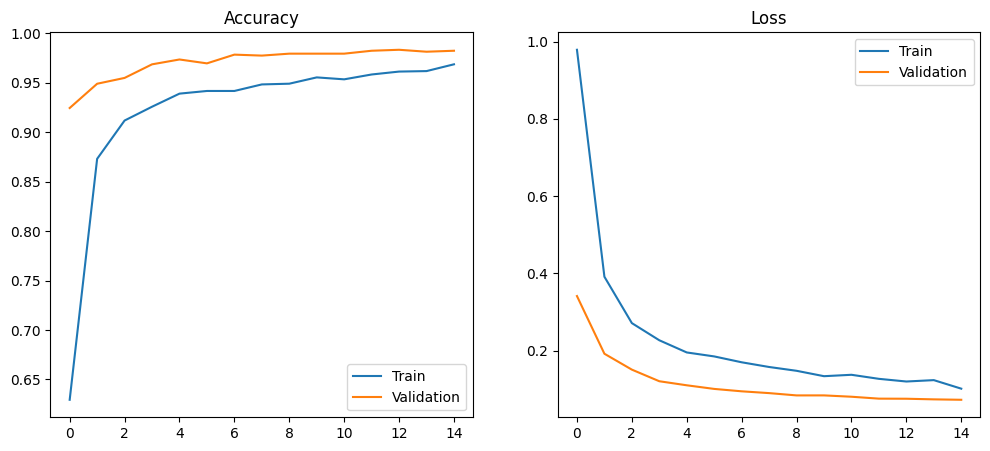

In [10]:
# -----------------------------
# VISUALIZATION
# -----------------------------

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

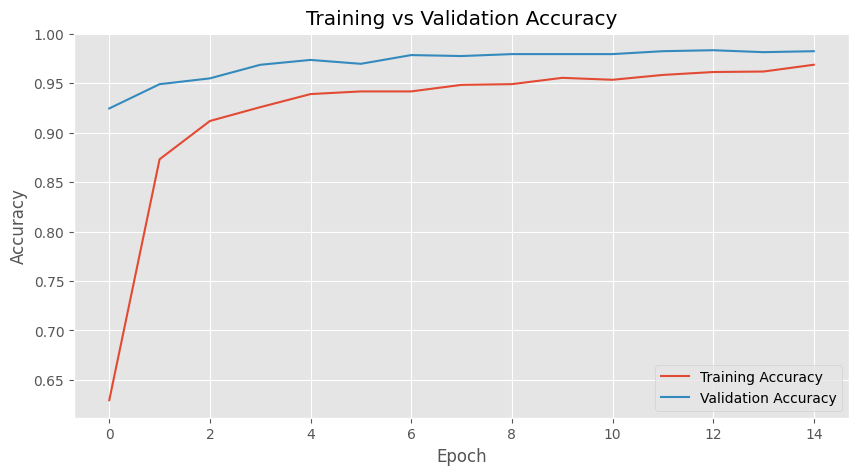

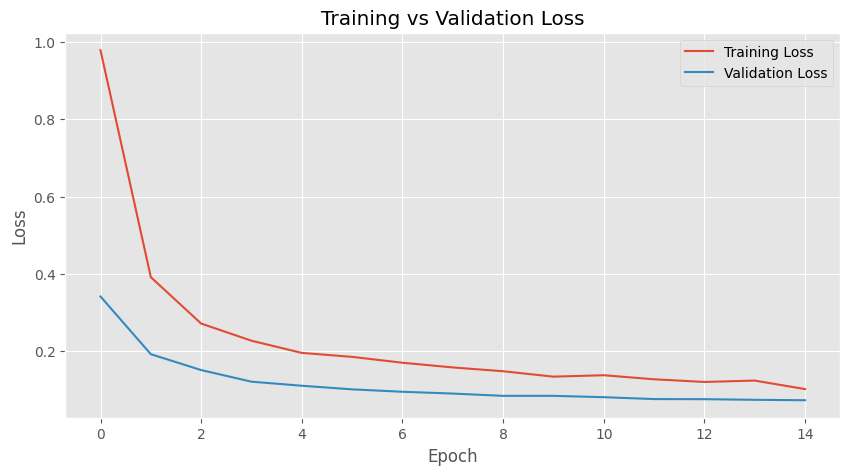

In [11]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

# Accuracy Graph
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("accuracy_graph.png")
plt.show()

# Loss Graph
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig("loss_graph.png")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

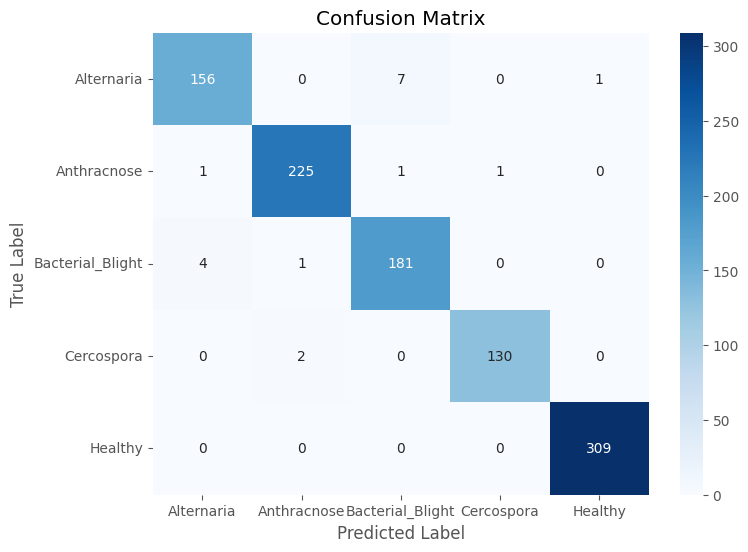

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    
    preds = model.predict(images)
    
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("confusion_matrix.png")

plt.show()

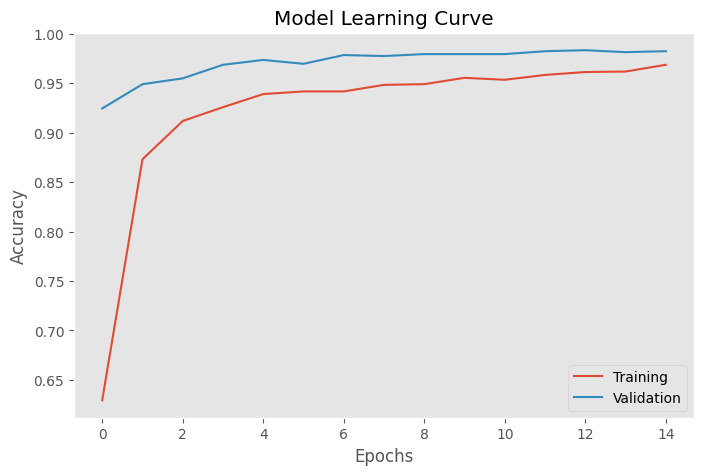

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Training")
plt.plot(history.history['val_accuracy'], label="Validation")

plt.title("Model Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.savefig("learning_curve.png")

plt.show()

In [14]:
import numpy as np
from sklearn.metrics import classification_report

# Collect true labels and predictions
y_true = []
y_pred = []

print("Generating predictions for metrics report...")
for images, labels in val_ds:
    # Convert one-hot labels back to class indices
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    
    # Predict and get the class with highest probability
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Print the classification table
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Generating predictions for metrics report...

Classification Report:
                  precision    recall  f1-score   support

      Alternaria       0.97      0.95      0.96       164
     Anthracnose       0.99      0.99      0.99       228
Bacterial_Blight       0.96      0.97      0.97       186
      Cercospora       0.99      0.98      0.99       132
         Healthy       1.00      1.00      1.00       309

        accuracy                           0.98      1019
       macro avg       0.98      0.98      0.98      1019
    weighted avg       0.98      0.98      0.98      1019



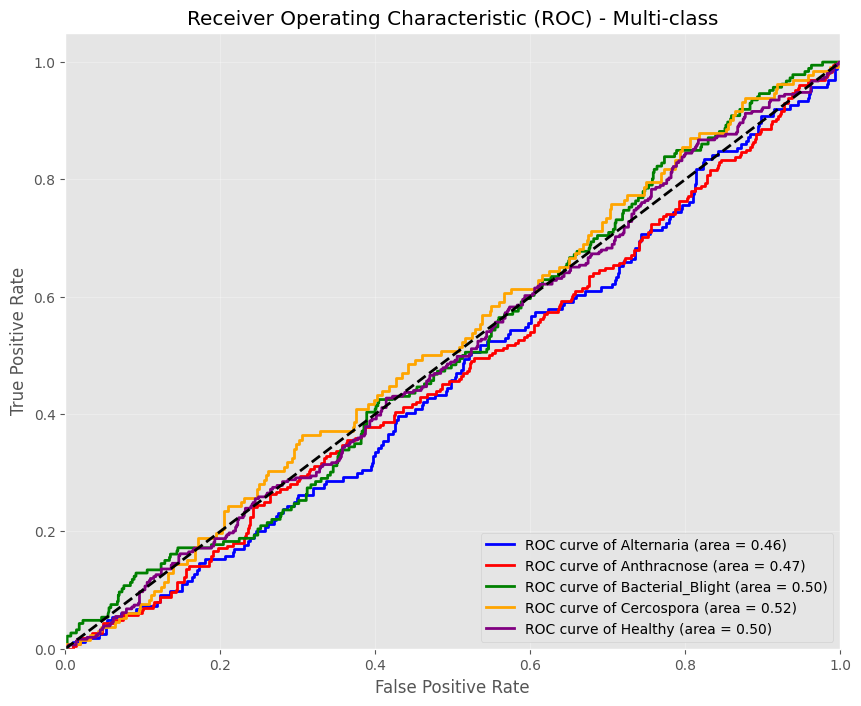

In [15]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Binarize labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

# 2. Get the probability scores (needed for AUC)
y_score = []
for images, _ in val_ds:
    y_score.extend(model.predict(images, verbose=0))
y_score = np.array(y_score)

# 3. Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plotting
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Multi-class')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()